Q1 Write a python program to Prepare Scatter Plot

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


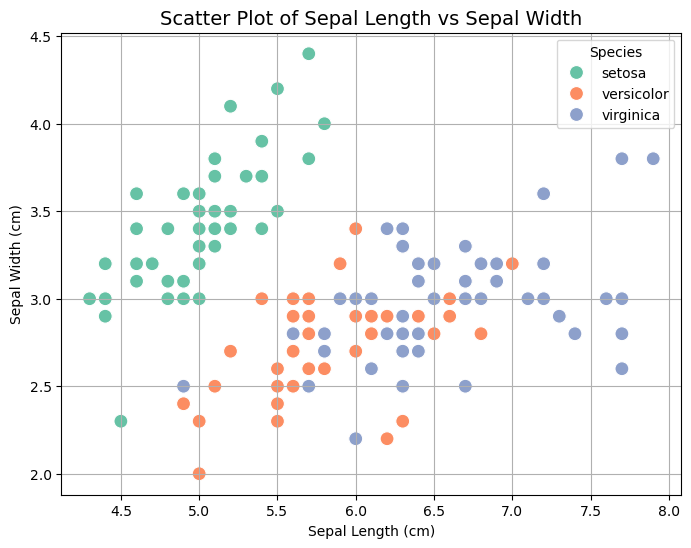

In [10]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = sns.load_dataset('iris')

# Display the first few rows (optional)
print(iris.head())

# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    hue='species',     # color by species
    palette='Set2',
    s=100              # size of points
)

# Add titles and labels
plt.title('Scatter Plot of Sepal Length vs Sepal Width', fontsize=14)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.grid(True)
plt.legend(title='Species')

# Show the plot
plt.show()


Q2) Write a python program to implement multiple Linear Regression for a given dataset. 

In [11]:
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [14]:
df=pd.read_csv("house_data.csv")
print(df.head())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [15]:
print(df.describe())
print(df.isnull().sum())
df=df.drop('date',axis=1)

                 id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580302e+09  5.400881e+05      3.370842      2.114757   2079.899736   
std    2.876566e+09  3.671272e+05      0.930062      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   1427.000000   
50%    3.904930e+09  4.500000e+05      3.000000      2.250000   1910.000000   
75%    7.308900e+09  6.450000e+05      4.000000      2.500000   2550.000000   
max    9.900000e+09  7.700000e+06     33.000000      8.000000  13540.000000   

           sqft_lot        floors    waterfront          view     condition  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  21613.000000   
mean   1.510697e+04      1.494309      0.007542      0.234303      3.409430   
std    4.142051e+04      0.539989      0.086517    

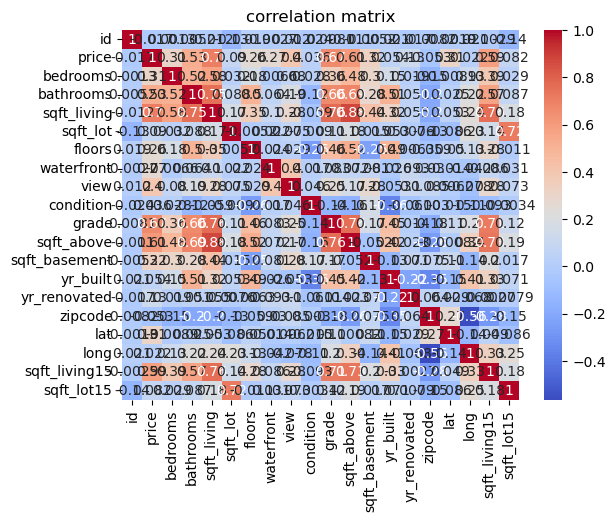

In [19]:
cm=df.corr()
sns.heatmap(cm,annot=True,cmap='coolwarm')
plt.title("correlation matrix")
plt.show()

In [25]:
x=df[['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition']]
y=df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("r-squared:",r2)


r-squared: 0.5633498429199127


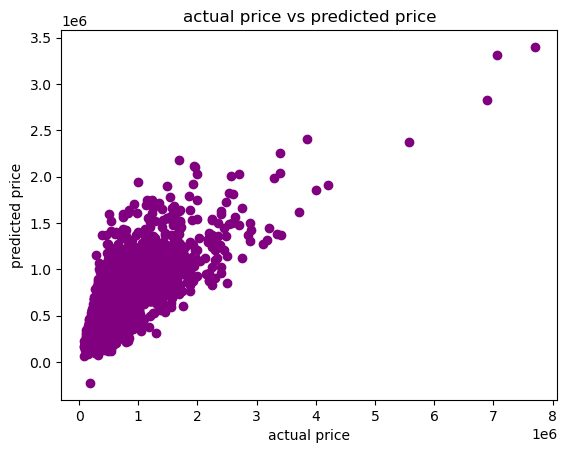

In [26]:
plt.scatter(y_test,y_pred,color="purple")
plt.title("actual price vs predicted price")
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.show()

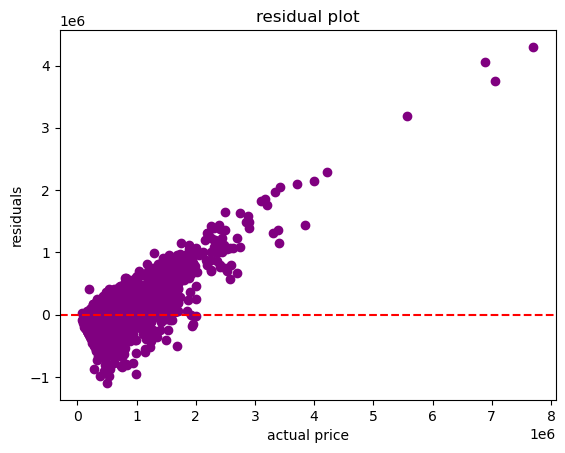

In [29]:
residuals=y_test-y_pred
plt.scatter(y_test,residuals,color="purple")
plt.axhline(y=0,color="red",linestyle='--')
plt.title("residual plot")
plt.xlabel("actual price")
plt.ylabel("residuals")
plt.show()

In [30]:
new_data=[[3,3,1500,4000,1,0,0,3]]
predicted_price=model.predict(new_data)
print("predicted price:",predicted_price[0])

predicted price: 352670.1458139276


C:\Users\Rajguru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


R-squared: 0.5633498429199127


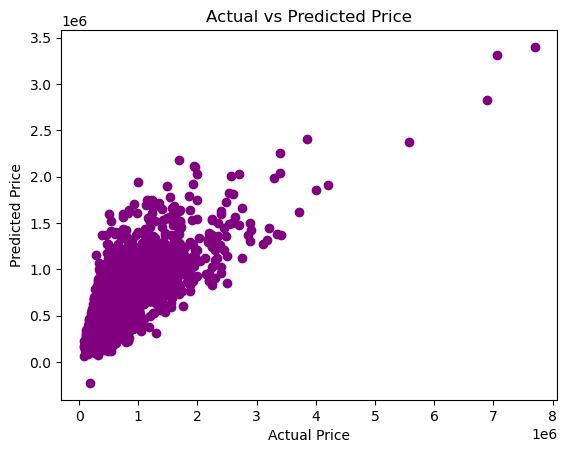

Predicted Price: 352670.1458139276


C:\Users\Rajguru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("house_data.csv")
df = df.drop('date', axis=1)

# Features and target
x = df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition']]
y = df['price']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3, random_state=0)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Predict and evaluate
y_pred = model.predict(x_test)
print("R-squared:", r2_score(y_test, y_pred))

# Actual vs Predicted plot
plt.scatter(y_test, y_pred, color="purple")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

# Predict new data
new_data = [[3, 3, 1500, 4000, 1, 0, 0, 3]]
predicted_price = model.predict(new_data)
print("Predicted Price:", predicted_price[0])


Q1) Write a python program to find all null values in a given data set and remove them

In [41]:
import pandas  as pd
import numpy as np
data={
    "first_score":[100,90,np.nan,97,45],
    "Second_score":[89,np.nan,78,np.nan,45],
    "Thire_score":[np.nan,np.nan,90,67,np.nan]}
df=pd.DataFrame(data)
print("Original dataset")
print(df)
print("\n null values in dataset")
print(df.isnull())
df_cleaned=df.dropna()
# Replace null values with a placeholder like '--'
df_display = df.fillna("--")

print("\nDataset (Only Actual Values Shown):")
print(df_display)


Original dataset
   first_score  Second_score  Thire_score
0        100.0          89.0          NaN
1         90.0           NaN          NaN
2          NaN          78.0         90.0
3         97.0           NaN         67.0
4         45.0          45.0          NaN

 null values in dataset
   first_score  Second_score  Thire_score
0        False         False         True
1        False          True         True
2         True         False        False
3        False          True        False
4        False         False         True

Dataset (Only Actual Values Shown):
  first_score Second_score Thire_score
0       100.0         89.0          --
1        90.0           --          --
2          --         78.0        90.0
3        97.0           --        67.0
4        45.0         45.0          --


Q2) Write a python program to implement simple Linear Regression for predicting
 house price. 

R-squared: 0.5000063123558642


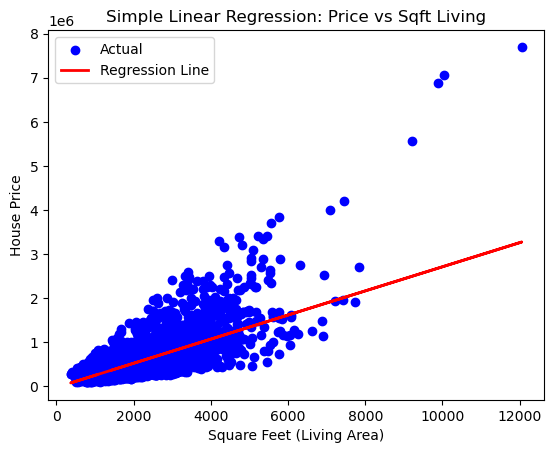

Predicted Price for 1500 sqft: 381663.0361435429


C:\Users\Rajguru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("house_data.csv")
df = df.drop('date', axis=1)

# Use only one feature (e.g., 'sqft_living') for simple linear regression
x = df[['sqft_living']]
y = df['price']

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=1/3, random_state=0)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Predict and evaluate
y_pred = model.predict(x_test)
print("R-squared:", r2_score(y_test, y_pred))

# Plot regression line with scatter plot
plt.scatter(x_test, y_test, color='blue', label='Actual')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Square Feet (Living Area)")
plt.ylabel("House Price")
plt.title("Simple Linear Regression: Price vs Sqft Living")
plt.legend()
plt.show()

# Predict price for a new input
new_sqft = [[1500]]
predicted_price = model.predict(new_sqft)
print("Predicted Price for 1500 sqft:", predicted_price[0]) 


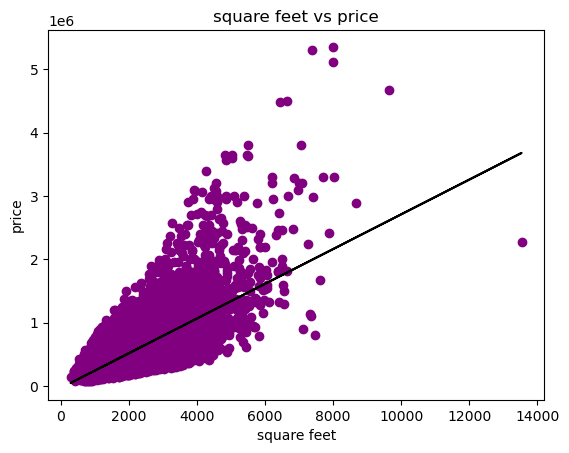

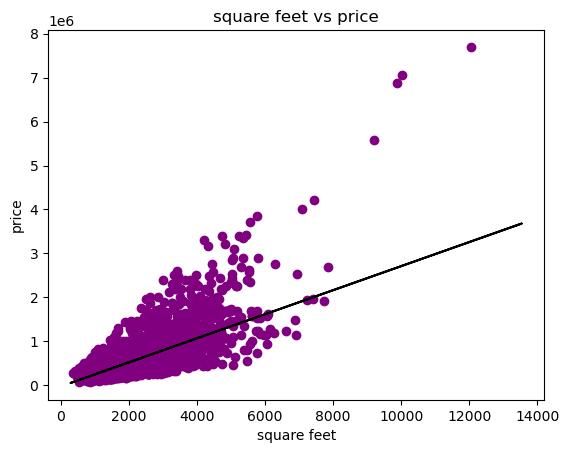

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
df=pd.read_csv("house_data.csv")
x = df[['sqft_living']]
y = df['price']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)
regressor=LinearRegression()
regressor.fit(x_train,y_train)
y_pred=regressor.predict(x_test)
x_pred=regressor.predict(x_train)
plt.scatter(x_train,y_train,color="purple")
plt.plot(x_train,x_pred,color="black")
plt.title("square feet vs price")
plt.xlabel("square feet")
plt.ylabel("price")
plt.show()

plt.scatter(x_test,y_test,color="purple")
plt.plot(x_train,x_pred,color="black")
plt.title("square feet vs price")
plt.xlabel("square feet")
plt.ylabel("price")
plt.show()

Q1) Write a python program the Categorical values in numeric format for a given dataset. 

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv("User_Data.csv")

print("Original Data:")
print(df.head())

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical columns found:", list(categorical_cols))

# Convert categorical columns to numeric using Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders if needed later

print("\nData after Label Encoding:")
print(df.head())



Original Data:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Categorical columns found: ['Gender']

Data after Label Encoding:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510       1   19            19000          0
1  15810944       1   35            20000          0
2  15668575       0   26            43000          0
3  15603246       0   27            57000          0
4  15804002       1   19            76000          0


In [12]:
#if you don't used csv file then code is the using DataFrame

import pandas as pd

# Cleaned-up data dictionary
data = {
    'Person': ['amit', 'vishal', 'Sindhu', 'Sanju', 'john', 'marry', 'sherin', 'komal', 'jay', 'shree', 'kishore',
               'geetha', 'savitha', 'vinith'],
    'Education': ['UnderGraduate', 'Diploma', 'Masters', 'Masters', 'UnderGraduate', 'Diploma', 'UnderGraduate',
                  'UnderGraduate', 'UnderGraduate', 'UnderGraduate', 'Diploma', 'Diploma', 'UnderGraduate', 'UnderGraduate'],
    'Salary(annum)': ['$90k', '$80k', '$160k', '$200k', '$90k', '$60k', '$90k', '$100k', '$60k', '$100k', '$90k',
                      '$70k', '$50k', '$90k']
}

# Create DataFrame
df = pd.DataFrame(data)


# One-hot encode 'Education'
dummies = pd.get_dummies(df['Education'], prefix='Edu').astype(int)

# Merge with original DataFrame (drop original Education column)
merged = pd.concat([df.drop('Education', axis=1), dummies], axis=1)

# Output result
print(merged)


     Person Salary(annum)  Edu_Diploma  Edu_Masters  Edu_UnderGraduate
0      amit          $90k            0            0                  1
1    vishal          $80k            1            0                  0
2    Sindhu         $160k            0            1                  0
3     Sanju         $200k            0            1                  0
4      john          $90k            0            0                  1
5     marry          $60k            1            0                  0
6    sherin          $90k            0            0                  1
7     komal         $100k            0            0                  1
8       jay          $60k            0            0                  1
9     shree         $100k            0            0                  1
10  kishore          $90k            1            0                  0
11   geetha          $70k            1            0                  0
12  savitha          $50k            0            0                  1
13   v

Q2) Write a python program to implement Polynomial Regression for given dataset. [

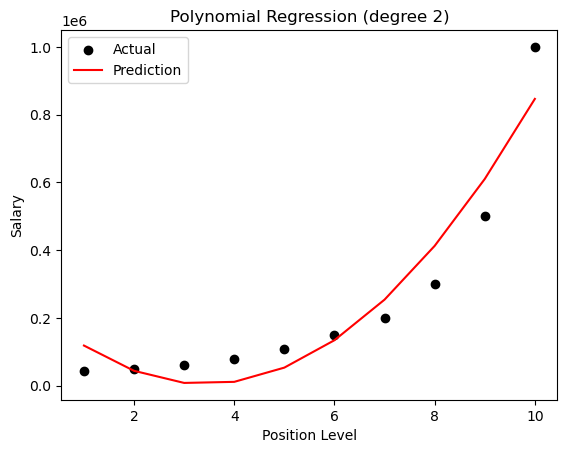

Predicted value is: 189498.10606060608


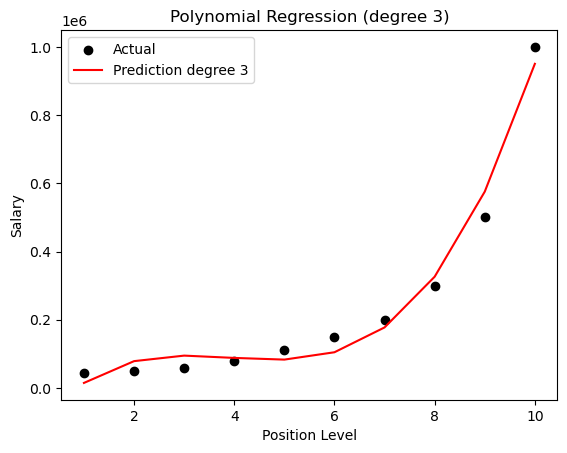

Predicted value is: 133259.4696969716


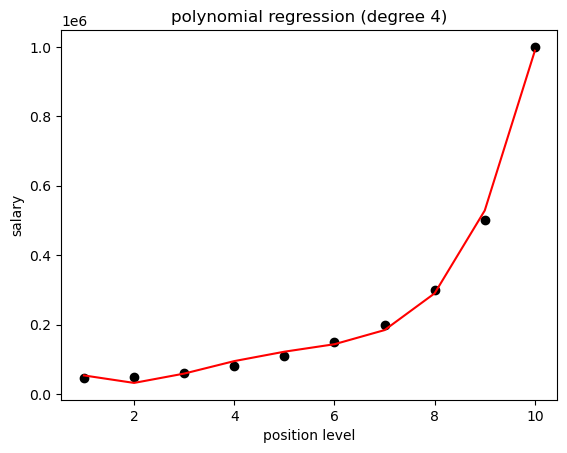

In [33]:
import pandas  as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

data=pd.read_csv("Position_salaries.csv")
x=data.iloc[:,1:2].values
y=data.iloc[:,2].values

poly_regs=PolynomialFeatures(degree=2)
x_poly=poly_regs.fit_transform(x)
lin_reg_2=LinearRegression()
lin_reg_2.fit(x_poly,y)

plt.scatter(x, y, color="black", label="Actual")
plt.plot(x, lin_reg_2.predict(x_poly), color="red", label="Prediction")
plt.title("Polynomial Regression (degree 2)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

# Prediction for level 6.5
poly_pred = lin_reg_2.predict(poly_regs.transform([[6.5]]))
print("Predicted value is:", poly_pred[0])

#degree 3
poly_regs=PolynomialFeatures(degree=3)
x_poly=poly_regs.fit_transform(x)
lin_reg_3=LinearRegression()
lin_reg_3.fit(x_poly,y)

plt.scatter(x, y, color="black", label="Actual")
plt.plot(x, lin_reg_3.predict(x_poly), color="red", label="Prediction degree 3")
plt.title("Polynomial Regression (degree 3)")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.legend()
plt.show()

# Prediction for level 6.5
poly_pred = lin_reg_3.predict(poly_regs.transform([[6.5]]))
print("Predicted value is:", poly_pred[0])

#degree 4
poly_regs=PolynomialFeatures(degree=4)
x_poly=poly_regs.fit_transform(x)
lin_regs_4=LinearRegression()
lin_regs_4.fit(x_poly,y)

plt.scatter(x,y,color="black",label="Actual")
plt.plot(x,lin_regs_4.predict(x_poly),color="red",label="predicted for degree 4")
plt.title("polynomial regression (degree 4)")
plt.xlabel("position level")
plt.ylabel("salary")
plt.show()


Write a python program to implement simple Linear Regression for predicting
House price. 

r-squared: 0.5000063123558642


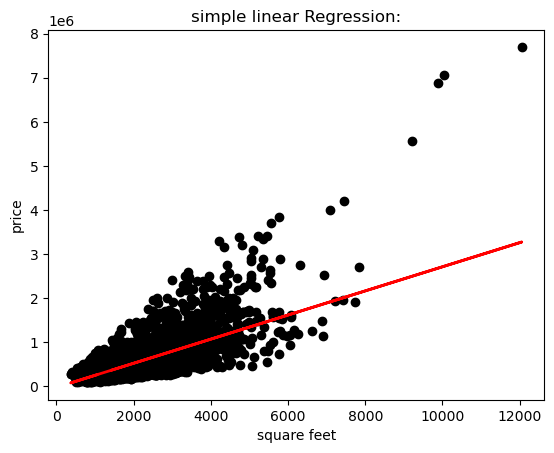

predicted price for 1540: 392615.10886027897


C:\Users\Rajguru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df=pd.read_csv("house_data.csv")
df=df.drop('date',axis=1)
x=df[['sqft_living']]
y=df['price']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)
model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
print("r-squared:",r2_score(y_test,y_pred))

plt.scatter(x_test,y_test,color="black",label="Actual")
plt.plot(x_test,y_pred,color="red",linewidth=2,label="RegressionLine")
plt.xlabel("square feet")
plt.ylabel("price")
plt.title("simple linear Regression:")
plt.show()

new_sqft=[[1540]]
predicted_price=model.predict(new_sqft)
print("predicted price for 1540:",predicted_price[0])

Q2) Write a python program to Implement Naïve Bayes. 

Accuracy: 0.9375

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95        52
           1       0.93      0.89      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



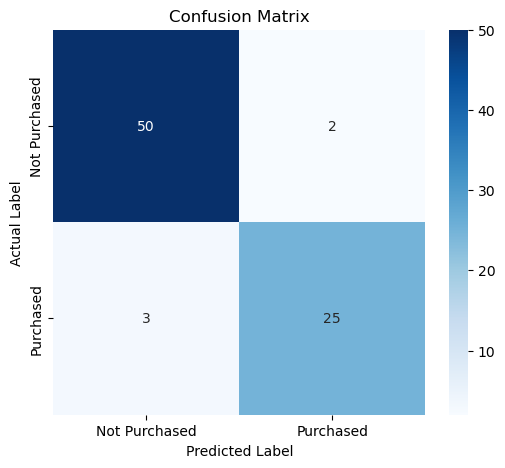

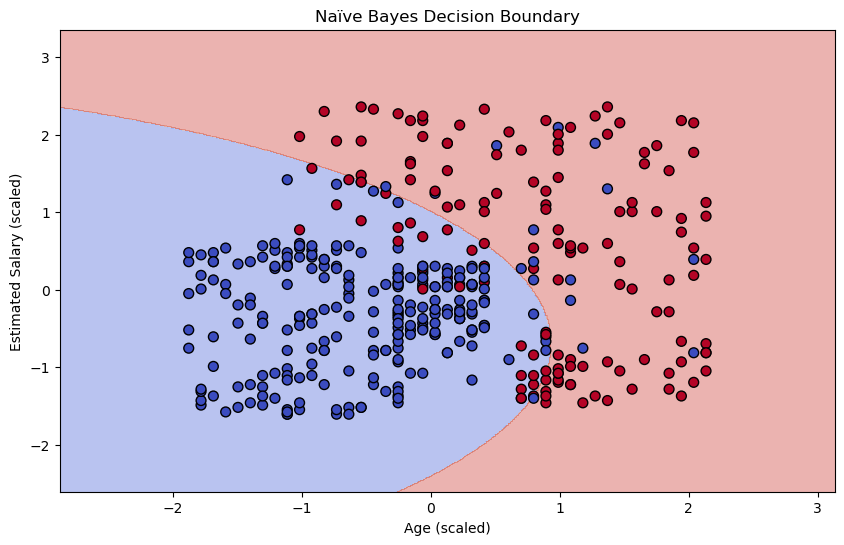

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# Load the dataset
data = pd.read_csv("User_Data.csv")

# Extract features and target
X = data[['Age', 'EstimatedSalary']]
y = data['Purchased']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# -------------------------
# 1. Confusion Matrix
# -------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d', xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# -------------------------
# 2. Scatter Plot with Decision Boundary
# -------------------------
# Create meshgrid
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict over the meshgrid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot contour and scatter
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=50, edgecolor='k', cmap='coolwarm')
plt.title('Naïve Bayes Decision Boundary')
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.show()


First 5 rows:
     User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None

Missing values:
 User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Class distribution:
 Purchased
0    257


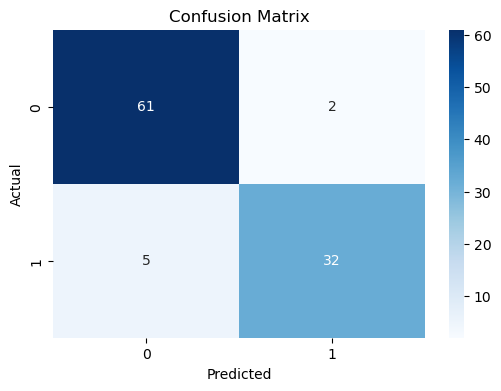

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
df = pd.read_csv("User_Data.csv")

# Step 2: Explore the dataset
print("First 5 rows:\n", df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['Purchased'].value_counts())

# Step 3: Preprocess the data
# Encode 'Gender' column if it exists
if 'Gender' in df.columns:
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

# Features and target
X = df[['Gender', 'Age', 'EstimatedSalary']]
y = df['Purchased']

# Optional: Feature scaling (recommended for GaussianNB)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)

# Step 5: Train Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Step 6: Predict and evaluate
y_pred = model.predict(X_test)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

# Step 7: Visualizing confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Q2)Write a python program to Implement Decision Tree whether or not to play tennis

Predictions for training data:
[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


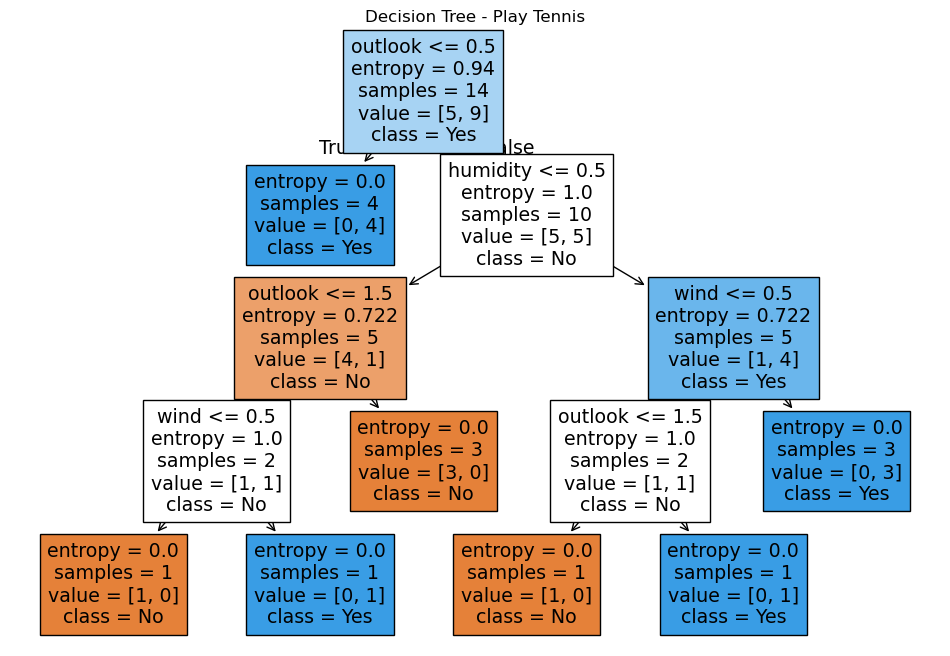

In [59]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Step 1: Load the CSV and clean column names
df = pd.read_csv('play_tennis.csv')
df.columns = df.columns.str.strip()  # Remove spaces

# Step 2: Drop 'day' column (not useful for prediction)
if 'day' in df.columns:
    df = df.drop('day', axis=1)

# Step 3: Encode categorical columns using LabelEncoder
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Step 4: Separate features and target
X = df.drop('play', axis=1)   # Features
y = df['play']                # Target

# Step 5: Train a Decision Tree model
model = DecisionTreeClassifier(criterion='entropy')  # Using ID3 algorithm
model.fit(X, y)

# Step 6: Predict on the same data (just for demo)
y_pred = model.predict(X)

# Step 7: Show predictions
print("Predictions for training data:")
print(y_pred)

# Step 8: Visualize the tree
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.title("Decision Tree - Play Tennis")
plt.show()


Q1) Write a python program to find all null values in a given data set and remove them

In [2]:
import pandas  as pd
import numpy as np
df=pd.read_csv("GOOG.csv")
print("print original dataset")
print(df.head())
print("\n null value in dataset ")
print(df.isnull())
df_cleaned=df.dropna()
df_display=df.fillna("--")
print("datset after doing task")
print(df_display.head())

print original dataset
  symbol                       date   close    high       low    open  \
0   GOOG  2016-06-14 00:00:00+00:00  718.27  722.47  713.1200  716.48   
1   GOOG  2016-06-15 00:00:00+00:00  718.92  722.98  717.3100  719.00   
2   GOOG  2016-06-16 00:00:00+00:00  710.36  716.65  703.2600  714.91   
3   GOOG  2016-06-17 00:00:00+00:00  691.72  708.82  688.4515  708.65   
4   GOOG  2016-06-20 00:00:00+00:00  693.71  702.48  693.4100  698.77   

    volume  adjClose  adjHigh    adjLow  adjOpen  adjVolume  divCash  \
0  1306065    718.27   722.47  713.1200   716.48    1306065      0.0   
1  1214517    718.92   722.98  717.3100   719.00    1214517      0.0   
2  1982471    710.36   716.65  703.2600   714.91    1982471      0.0   
3  3402357    691.72   708.82  688.4515   708.65    3402357      0.0   
4  2082538    693.71   702.48  693.4100   698.77    2082538      0.0   

   splitFactor  
0          1.0  
1          1.0  
2          1.0  
3          1.0  
4          1.0  

 n

Q2) Write a python program to Implement Naïve Bayes. 

First 5 rows of the dataset:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

Missing Values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

Accuracy of the model: 0.925

Confusion Matrix:
[[56  2]
 [ 4 18]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        58
           1       0.90      0.82      0.86        22

    accuracy                           0.93        80
   macro avg       0.92      0.89      0.90        80
weighted avg       0.92      0.93      0.92        80



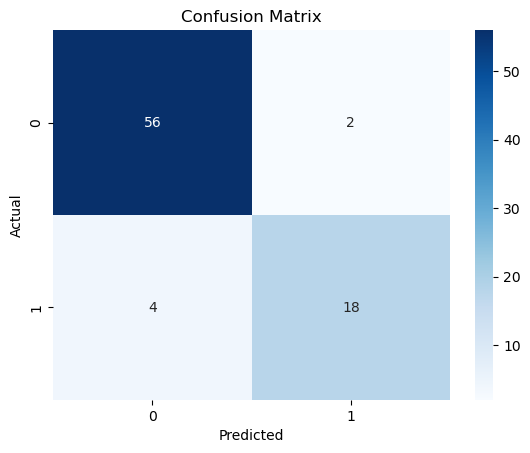

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load your dataset
df = pd.read_csv('User_Data.csv')
print("First 5 rows of the dataset:")
print(df.head())

# Step 3: Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Step 4: Convert 'Gender' from text to numbers (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Step 5: Select features (X) and target (y)
X = df[['Gender', 'Age', 'EstimatedSalary']]  # Features
y = df['Purchased']                          # Target

# Step 6: Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Step 7: Create and train the Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# Step 8: Make predictions on test data
y_pred = model.predict(X_test)

# Step 9: Evaluate the model
print("\nAccuracy of the model:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 10: Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Q1) Write a python program to implement linear SVM

accuracy: 0.9

 classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        68
           1       0.92      0.75      0.83        32

    accuracy                           0.90       100
   macro avg       0.91      0.86      0.88       100
weighted avg       0.90      0.90      0.90       100



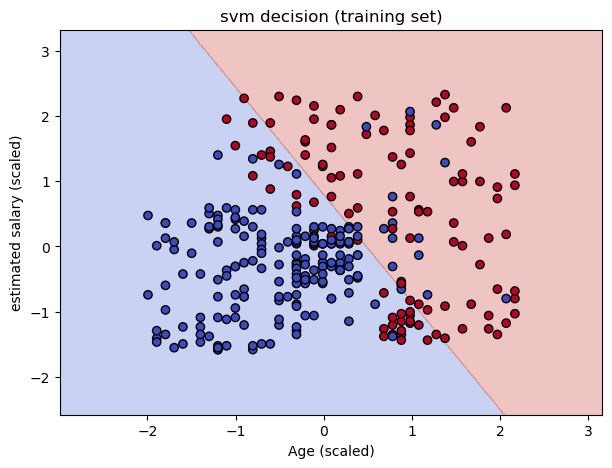

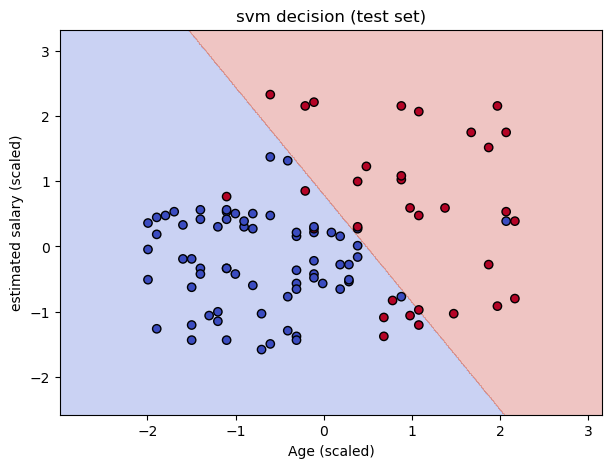

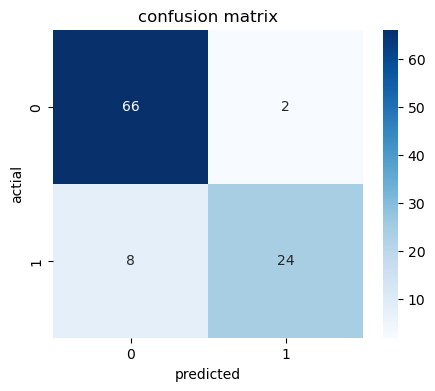

In [16]:
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import numpy as np
data=pd.read_csv("User_Data.csv")
x=data[['Age','EstimatedSalary']]
y=data['Purchased']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

model=SVC(kernel='linear')
model.fit(x_train_scaled,y_train)

y_pred=model.predict(x_test_scaled)
print("accuracy:",accuracy_score(y_test,y_pred))
print("\n classification Report:\n",classification_report(y_test,y_pred))

def plot_decision_boundary(x,y,title):
    x=x.values if isinstance(x,pd.DataFrame) else x
    x1,x2=np.meshgrid(
        np.arange(start=x[:, 0].min() -1,stop=x[:, 0].max() +1,step=0.01),
        np.arange(start=x[:, 1].min() -1,stop=x[:, 1].max() +1,step=0.01)
    )
    plt.figure(figsize=(7,5))
    plt.contourf(x1,x2,model.predict(np.c_[x1.ravel(),x2.ravel()]).reshape(x1.shape),
                 alpha=0.3,cmap='coolwarm')
    plt.scatter(x[:,0],x[:,1],c=y,cmap='coolwarm',edgecolors='k')
    plt.title(title)
    plt.xlabel('Age (scaled)')
    plt.ylabel('estimated salary (scaled)')
    plt.show()

plot_decision_boundary(pd.DataFrame(x_train_scaled),y_train,"svm decision (training set)")
plot_decision_boundary(pd.DataFrame(x_test_scaled),y_test,"svm decision (test set)")
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test,y_pred)
            ,annot=True,fmt='d',cmap="Blues")
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actial")
plt.show()